# Brain Tumor Segmentation using BraTS2020

## Computer Vision Module

This notebook is the first step in developing the Computer Vision pipeline for our multimodal brain tumor analysis project.

Rather than building a model immediately, the goal of this notebook is to understand the dataset, its organization, medical imaging modalities, and the segmentation task.

A solid understanding of the dataset is essential before designing preprocessing pipelines or training deep learning models.

# Project Overview

This project aims to build an automated brain tumor segmentation system using the BraTS2020 dataset.

The segmented tumor regions and extracted image features will later be integrated with clinical text information through a multimodal fusion framework.

The Computer Vision module is responsible for:

- Understanding the dataset.
- Preparing MRI volumes.
- Building the segmentation model.
- Extracting image features.
- Providing outputs for the Fusion module.

# What is BraTS2020?

The Brain Tumor Segmentation (BraTS) Challenge is an international benchmark designed to advance research in automatic brain tumor analysis using magnetic resonance imaging (MRI).

The BraTS2020 dataset contains pre-operative multi-modal MRI scans collected from multiple medical institutions.

Each patient includes four MRI modalities together with expert-annotated segmentation masks.

The dataset is widely used for developing and evaluating deep learning models for medical image segmentation.

# Challenge Objective

The primary task addressed in this project is:

**Brain Tumor Segmentation**

Given a patient's MRI scans, the model should automatically identify and segment different tumor regions.

Unlike image classification, segmentation predicts a label for every voxel (3D pixel) in the MRI volume, allowing precise localization of tumor tissues.

# Dataset Structure

The original BraTS2020 dataset is organized on a patient basis.

Each patient is stored inside a separate folder.

Every folder contains five NIfTI (.nii.gz) files representing four MRI modalities and one expert-annotated segmentation mask.

This organization allows each patient to be treated as a complete 3D medical imaging study.

In [1]:
from pathlib import Path

DATASET_PATH = Path("/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

In [2]:
patients = sorted([p for p in DATASET_PATH.iterdir() if p.is_dir()])

print(f"Number of Patients: {len(patients)}")

Number of Patients: 369


# Inspecting Patient Folders

Each folder represents one patient.

We first inspect one patient to understand the available files before loading any MRI volumes.

In [3]:
sample_patient = patients[0]

print(sample_patient.name)

BraTS20_Training_001


In [4]:
for file in sorted(sample_patient.iterdir()):
    print(file.name)

BraTS20_Training_001_flair.nii
BraTS20_Training_001_seg.nii
BraTS20_Training_001_t1.nii
BraTS20_Training_001_t1ce.nii
BraTS20_Training_001_t2.nii


# Understanding the Dataset Files

| File | Description |
|------|-------------|
| T1 | Anatomical MRI image |
| T1ce | Contrast-enhanced MRI highlighting active tumor regions |
| T2 | Highlights edema and fluid accumulation |
| FLAIR | Suppresses cerebrospinal fluid and enhances lesion visibility |
| Seg | Ground truth segmentation mask created by expert radiologists |

# What is a NIfTI File?

Unlike conventional image datasets (PNG or JPEG), medical imaging datasets are commonly stored using the NIfTI format (.nii or .nii.gz).

A single NIfTI file represents an entire three-dimensional MRI volume rather than a single image.

Each volume consists of multiple consecutive slices that together reconstruct the patient's brain.

# Loading a 3D MRI Volume

In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [6]:
t1_path = next(sample_patient.glob("*_t1.nii"))

t1_img = nib.load(str(t1_path))

t1_volume = t1_img.get_fdata()

## MRI Volume Properties

After loading the first MRI volume, we inspect its basic properties.

Understanding the volume dimensions and intensity values is important before applying any preprocessing techniques.

The MRI volume is represented as a three-dimensional NumPy array where:

- The first dimension represents the image height.
- The second dimension represents the image width.
- The third dimension represents the sequence of MRI slices.

In [7]:
print("MRI Shape:", t1_volume.shape)
print("Data Type:", t1_volume.dtype)
print("Minimum Intensity:", np.min(t1_volume))
print("Maximum Intensity:", np.max(t1_volume))

MRI Shape: (240, 240, 155)
Data Type: float64
Minimum Intensity: 0.0
Maximum Intensity: 678.0


### Observation

From the first MRI volume we observe:

- The MRI scan has a shape of **(240, 240, 155)**.
- The volume consists of **155 axial slices**.
- Pixel intensities range from **0** to **678**.
- The MRI is stored as floating-point values.

These observations will guide the preprocessing stage, especially intensity normalization.

# Understanding MRI Volumes

Unlike natural image datasets, a single sample in BraTS2020 is **not a single image**.

Instead, each patient is represented by a complete three-dimensional MRI volume.

A volume consists of multiple consecutive slices that together reconstruct the patient's brain anatomy.

Therefore:

- One patient = One MRI study
- One MRI study = Four MRI volumes
- One MRI volume = Multiple 2D slices

## Visualizing MRI Slices

To better understand the MRI data, we display one slice from the middle of the volume.

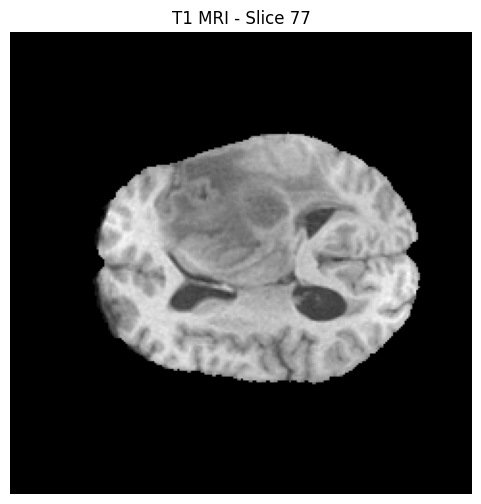

In [8]:
slice_idx = t1_volume.shape[-1] // 2

plt.figure(figsize=(6,6))

plt.imshow(
    t1_volume[:, :, slice_idx],
    cmap="gray"
)

plt.title(f"T1 MRI - Slice {slice_idx}")

plt.axis("off")

plt.show()

### Observation

The displayed slice represents a single cross-sectional view of the brain.

A complete MRI volume contains multiple such slices, which together preserve the three-dimensional anatomical structure.

Deep learning models designed for medical image segmentation can utilize either individual slices (2D models) or the complete volume (3D models).

# Loading the Segmentation Mask

Each patient includes a manually annotated segmentation mask created by expert neuroradiologists.

The mask identifies different tumor subregions and serves as the ground truth during model training.

In [9]:
seg_path = next(sample_patient.glob("*_seg.nii"))

seg_img = nib.load(str(seg_path))

seg_volume = seg_img.get_fdata()

In [10]:
print(seg_volume.shape)

print(np.unique(seg_volume))

(240, 240, 155)
[0. 1. 2. 4.]


# Visualizing the Segmentation Mask

The segmentation mask represents the ground truth annotation provided by expert neuroradiologists.

Each voxel inside the mask belongs to one of several tumor subregions.

Before training any segmentation model, it is important to inspect the mask visually.

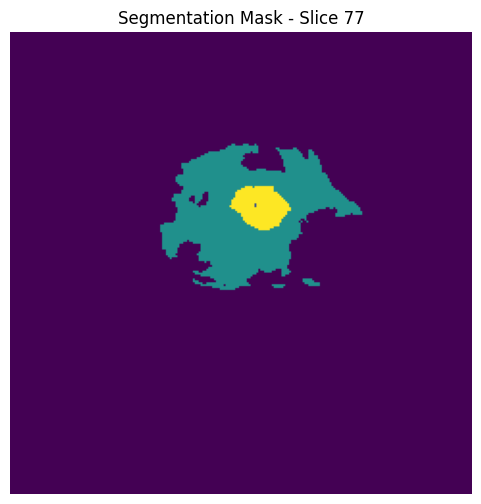

In [11]:
slice_idx = seg_volume.shape[-1] // 2

plt.figure(figsize=(6,6))

plt.imshow(seg_volume[:, :, slice_idx])

plt.title(f"Segmentation Mask - Slice {slice_idx}")

plt.axis("off")

plt.show()

### Observation

The segmentation mask contains multiple tumor subregions rather than a single binary mask.

The detected labels are:

- **0** → Background
- **1** → Necrotic and Non-Enhancing Tumor Core (NCR/NET)
- **2** → Peritumoral Edema (ED)
- **4** → Enhancing Tumor (ET)

These pixel-level annotations will be used as the ground truth during model training.

# MRI and Segmentation Overlay

Overlaying the segmentation mask on top of the MRI image helps verify that the annotations are correctly aligned with the anatomical structures.

This visual inspection is an important quality check before proceeding to preprocessing and model development.

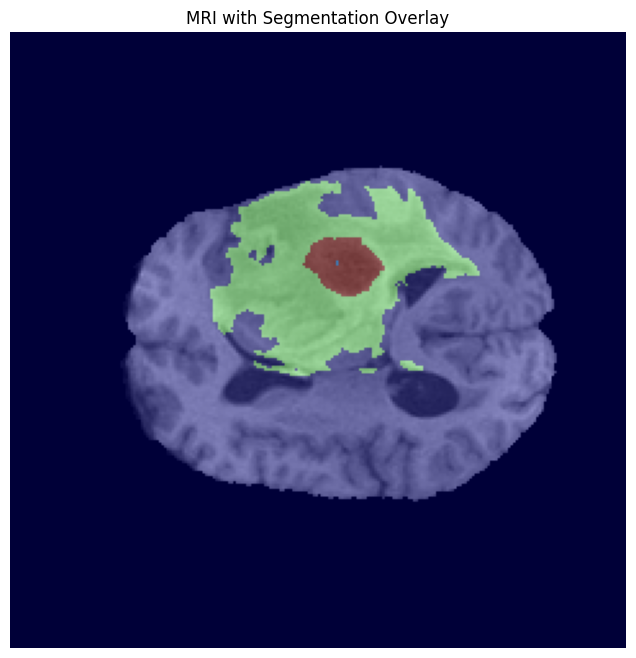

In [12]:
plt.figure(figsize=(8, 8))

plt.imshow(
    t1_volume[:, :, slice_idx],
    cmap="gray"
)

plt.imshow(
    seg_volume[:, :, slice_idx],
    cmap="jet",
    alpha=0.45
)

plt.title("MRI with Segmentation Overlay")

plt.axis("off")

plt.show()

### Observation

The overlay confirms that the segmentation mask is accurately aligned with the anatomical MRI image.

The tumor subregions appear in anatomically meaningful locations, with the edema surrounding the tumor core as expected.

No noticeable spatial misalignment is observed between the MRI volume and its corresponding segmentation mask.

This confirms that the dataset is correctly registered and suitable for developing a 3D brain tumor segmentation pipeline.

# Dataset Information Card

The following table summarizes the key characteristics of the BraTS2020 dataset explored in this notebook.

| Property | Value |
|----------|-------|
| Dataset Name | Brain Tumor Segmentation (BraTS2020) |
| Task | 3D Brain Tumor Segmentation |
| Number of Patients | 369 |
| MRI Modalities | T1, T1ce, T2, FLAIR |
| Ground Truth | Expert-annotated Segmentation Mask |
| File Format | `.nii` |
| MRI Volume Shape | (240 × 240 × 155) |
| Segmentation Labels | 0, 1, 2, 4 |
| Data Type | 3D Medical Images |
| Framework (Planned) | PyTorch + MONAI |

# References

The following resources were used to understand the dataset and medical imaging concepts:

1. BraTS 2020 Challenge Documentation.
2. MONAI Documentation.
3. NiBabel Documentation.
4. PyTorch Documentation.
5. Original BraTS Publications.

# Notebook Summary

In this notebook, we explored the BraTS2020 dataset and gained a comprehensive understanding of its structure.

### We accomplished the following:

- Introduced the BraTS2020 challenge.
- Explored the dataset organization.
- Inspected patient folders.
- Understood the MRI modalities.
- Loaded and visualized a 3D MRI volume.
- Loaded and inspected the segmentation mask.
- Verified the alignment between MRI volumes and segmentation masks.
- Summarized the key characteristics of the dataset.

The dataset is now fully understood and ready for comprehensive validation and preprocessing in the next stage.